Reinforcement Learning\
Restaraunt Inventory Management

`State Space` $S$: Number of units of fresh ingredients currently in Fridge (0,5,10 etc)

`Action Space` $A$: How many new units to order for tomorrow morning (0,1,2... MAX)

`Reward` $R$:
* (+) Money made from customers who ordered a meal

* (-) Money lost for every unit that expired at the end of the day
* (-) A "reputation cost" or lost sale if a customer wanted a meal but you were out of ingredients.

`Transitions` $P$: Based on the probability of "Busy", "Normal" or "Slow" Dinner rushes

`Discount Factor`:
High $\gamma$ (>.95): Agent is willing to spend money on inventory now because they understand that having food in stock for the next few days leads to long-term steady profit.

Low $\gamma$ (<0.5): Agent sees the cost of ordering food right now as a massive negative and don't care that they will have nothing to sell tomorrow. They might eventually learn to never order anything just to keep their current balance from dropping.

In [8]:
import numpy as np
from scipy.stats import poisson

class RestaurantMDP:
    def __init__(self, max_capacity=10, mean_demand=3, gamma=0.9,
                 price=10, cost=2, waste_penalty=5, stockout_penalty=8):
        self.S = range(max_capacity + 1)  # States: 0 to 10 units
        self.A = range(max_capacity + 1)  # Actions: order 0 to 10 units
        self.gamma = gamma
        self.max_cap = max_capacity
        self.price = price
        self.cost = cost
        self.waste_penalty = waste_penalty
        self.stockout_penalty = stockout_penalty

        # Pre-calculate probabilities for customer demand (Poisson distribution)
        self.demand_probs = [poisson.pmf(d, mean_demand) for d in range(max_capacity + 5)]

    def calculate_q(self, s, a, V):
        """Returns expected value for a state-action pair (Q-value)"""
        expected_val = 0
        current_total = min(s + a, self.max_cap) # Inventory after restocking

        for demand, prob in enumerate(self.demand_probs):
            if prob < 0.001: continue

            sold = min(current_total, demand)
            leftover = current_total - sold
            unmet_demand = max(0, demand - current_total)

            # Reward = Revenue - Order Cost - Waste - Stockout Penalty
            reward = (sold * self.price) - \
                     (a * self.cost) - \
                     (leftover * self.waste_penalty) - \
                     (unmet_demand * self.stockout_penalty)

            # In a perishable model, next state is what's left (or 0 if it spoils)
            next_state = leftover
            expected_val += prob * (reward + self.gamma * V[next_state])

        return expected_val

Using Value Iteration

In [4]:
def value_iteration(mdp, theta=0.0001):
    V = np.zeros(len(mdp.S))
    policy = np.zeros(len(mdp.S), dtype=int)

    while True:
        delta = 0
        for s in mdp.S:
            v_old = V[s]
            # Calculate quality (Q-value) for each action
            action_values = []
            for a in mdp.A:
                # Calculate the expected reward for this action
                val = mdp.calculate_q(s, a, V)
                action_values.append(val)

            V[s] = max(action_values)
            delta = max(delta, abs(v_old - V[s]))

        if delta < theta: break # Converged

    # Extract the final policy
    for s in mdp.S:
        policy[s] = np.argmax([mdp.calculate_q(s, a, V) for a in mdp.A])

    return V, policy


In [9]:
# Create the environment
env = RestaurantMDP(gamma=0.9)

# Run the solver
optimal_V, optimal_policy = value_iteration(env)

#  Print the results for your report
print("Optimal Policy (Inventory -> Amount to Order):")
for state, action in enumerate(optimal_policy):
    print(f"If fridge has {state} units -> Order {action} units")

Optimal Policy (Inventory -> Amount to Order):
If fridge has 0 units -> Order 4 units
If fridge has 1 units -> Order 3 units
If fridge has 2 units -> Order 2 units
If fridge has 3 units -> Order 1 units
If fridge has 4 units -> Order 0 units
If fridge has 5 units -> Order 0 units
If fridge has 6 units -> Order 0 units
If fridge has 7 units -> Order 0 units
If fridge has 8 units -> Order 0 units
If fridge has 9 units -> Order 0 units
If fridge has 10 units -> Order 0 units


### Optimal Value Function

In [10]:
print("Optimal Value Function (State -> Value):")
for state, value in enumerate(optimal_V):
    print(f"If fridge has {state} units -> Value: {value:.2f}")

Optimal Value Function (State -> Value):
If fridge has 0 units -> Value: 119.29
If fridge has 1 units -> Value: 121.29
If fridge has 2 units -> Value: 123.29
If fridge has 3 units -> Value: 125.29
If fridge has 4 units -> Value: 127.28
If fridge has 5 units -> Value: 127.92
If fridge has 6 units -> Value: 126.12
If fridge has 7 units -> Value: 122.58
If fridge has 8 units -> Value: 117.51
If fridge has 9 units -> Value: 110.94
If fridge has 10 units -> Value: 102.90


 Varying the Discount Factor

In [11]:
# lower gamma
env_low_gamma = RestaurantMDP(gamma=0.5)

optimal_V_low_gamma, optimal_policy_low_gamma = value_iteration(env_low_gamma)

print("Optimal Policy with gamma = 0.5 (Inventory -> Amount to Order):")
for state, action in enumerate(optimal_policy_low_gamma):
    print(f"If fridge has {state} units -> Order {action} units")

Optimal Policy with gamma = 0.5 (Inventory -> Amount to Order):
If fridge has 0 units -> Order 4 units
If fridge has 1 units -> Order 3 units
If fridge has 2 units -> Order 2 units
If fridge has 3 units -> Order 1 units
If fridge has 4 units -> Order 0 units
If fridge has 5 units -> Order 0 units
If fridge has 6 units -> Order 0 units
If fridge has 7 units -> Order 0 units
If fridge has 8 units -> Order 0 units
If fridge has 9 units -> Order 0 units
If fridge has 10 units -> Order 0 units


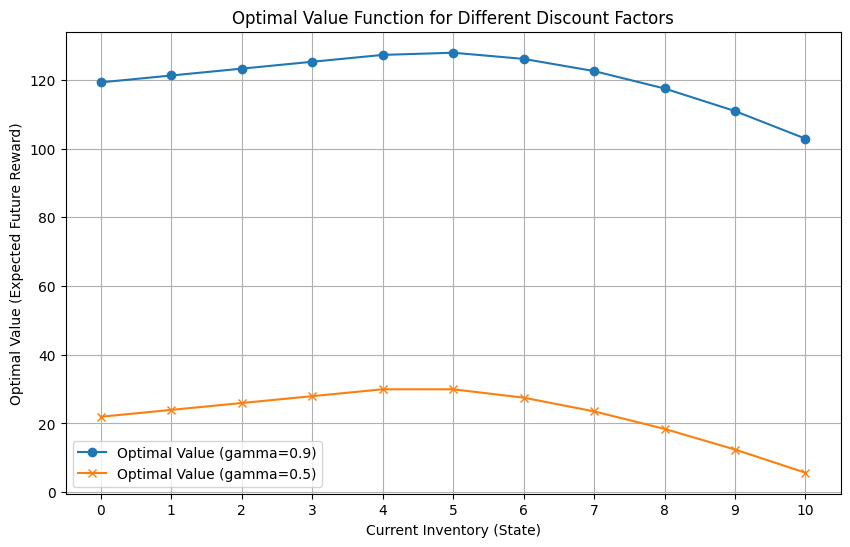

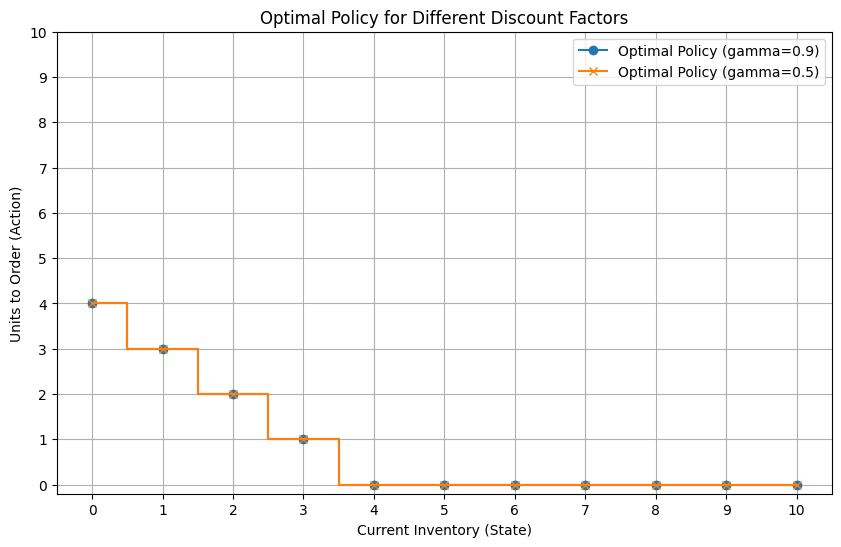

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(env.S, optimal_V, label=f'Optimal Value (gamma={env.gamma})', marker='o')
plt.plot(env_low_gamma.S, optimal_V_low_gamma, label=f'Optimal Value (gamma={env_low_gamma.gamma})', marker='x')
plt.title('Optimal Value Function for Different Discount Factors')
plt.xlabel('Current Inventory (State)')
plt.ylabel('Optimal Value (Expected Future Reward)')
plt.xticks(list(env.S))
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.step(env.S, optimal_policy, where='mid', label=f'Optimal Policy (gamma={env.gamma})', marker='o')
plt.step(env_low_gamma.S, optimal_policy_low_gamma, where='mid', label=f'Optimal Policy (gamma={env_low_gamma.gamma})', marker='x')
plt.title('Optimal Policy for Different Discount Factors')
plt.xlabel('Current Inventory (State)')
plt.ylabel('Units to Order (Action)')
plt.xticks(list(env.S))
plt.yticks(list(env.A))
plt.grid(True)
plt.legend()
plt.show()

Through the code we can highlight the MDP nature as we satisfy the conditions for an MDP with States, Actions, Transitions, Rewards, Discount factors.

With the learned policy we can see that the optimal policy for gamma =0.9 shows that if the fridge has 0-3 units the policy recommends ordering enough to bring the total close to 4 units. Which suggests the model prioritizes having enough stock to meet expected demand.

With 4-10 units the policy recommends 0 which implies that having 4 or more units is sufficient to cover expected demand and ordering more would lead to waste .

Now with gamma =0.5 the output is identical which suggests that the immediate costs like ordering, waste and stockout are so significant that even with a lower emphasis on  future rewards the optimal strategy remains to maintain a certain inventory level to balance these immediate penalties.

With the graphs we notice the significance in the blue and orange due to the expected nature of a higher discount factor means future rewards are valued more heavily leading to higher cumulative expected rewards over the long term

#Part 2

Select one focused topic and identify at least two technical sources. At least one source should
be a primary source such as a research paper, official documentation, or a model card.

• Explain the problem the method is trying to solve, the core idea behind the method, and the main
architecture or training objective in your own words.

• Include one small hands-on component. For example, you may run a simple demo, inspect a
pretrained model or pipeline, reproduce one small figure or result, compare two variants, or
analyze how one key design choice affects outputs.

• If you choose diffusion models, possible hands-on directions include comparing different
numbers of denoising steps, comparing schedulers, testing prompt sensitivity, or explaining the
forward and reverse diffusion process with a compact experiment.

• Include at least one figure, table, or carefully labeled output example that supports your analysis.

• Discuss at least two limitations, risks, or open challenges related to the method.

• Propose one concrete extension, improvement, or follow-up experiment that you would pursue
next.


## Diffusion Models

Sources: https://huggingface.co/docs/diffusers/index, https://arxiv.org/abs/2006.11239

### Problem Trying Solve
The problem Diffusion Models try to solve is that generative AI was creating a high-resolution diverse images without in GANs. Diffusion models solve this by breaking the generation process into many small,, iterative denoising step, making the learning process more stable and reliable

### Core Idea
The model learns to "denoise" an image by predicting the specific noise added at each step. By starting with pure Gaussian noise, a clear and structure image emerges from the static

###  Main Architecutre or Training Objective
The common architecture is a U-Net, which is trained with objective of noise estimation. Where in training the the model is showna noisy image and tasked with predicting exactly what noise was added to it.

### Include one small hands-on component, explaining the forward and reverse diffusion process with a compact experiment.

Include at least one figure, table, or carefully labeled output example that supports your analysis.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

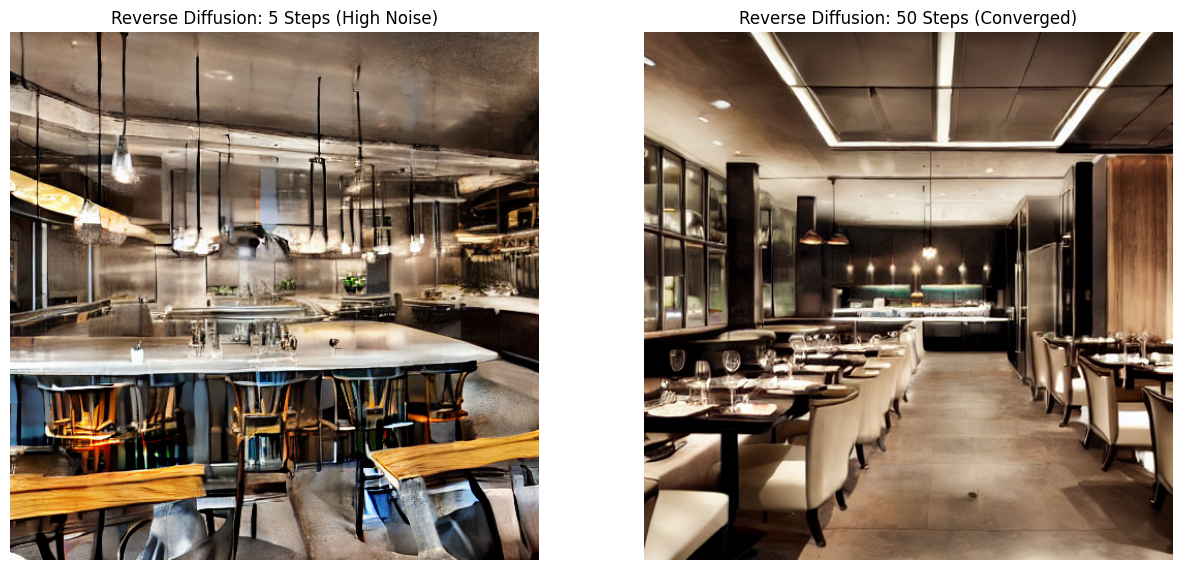

In [1]:

!pip install diffusers transformers accelerate -q

from diffusers import StableDiffusionPipeline
import torch
import matplotlib.pyplot as plt

# Load the Pre-trained Pipeline
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

prompt = "A high-end restaurant kitchen with fresh ingredients, cinematic lighting"
generator = torch.Generator("cuda").manual_seed(42)

image_5 = pipe(prompt, num_inference_steps=5, generator=generator).images[0]
image_50 = pipe(prompt, num_inference_steps=50, generator=generator).images[0]

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(image_5)
ax[0].set_title("Reverse Diffusion: 5 Steps (High Noise)")
ax[0].axis("off")

ax[1].imshow(image_50)
ax[1].set_title("Reverse Diffusion: 50 Steps (Converged)")
ax[1].axis("off")

plt.show()

Propose one concrete extension, improvement, or follow-up experiment that you would pursue
next.


A major limitation of standard Diffusion Models is the lack of precise spatial control while the model can generate a restaraunt it cant place a stove or table in a specific coordinate. My proposed follow up would involve integrating ControlNet that would allow the model to accept additional conditioning like edge maps or depth cues. By prviding as rough sketcgh of a restauraunts floor plan as an input I would evaluate how much spatial consistency improves compared to a  text only . This would transform the model from a creative tool into a functional design utility for restaraunt management scenario